# Summarizing Messages

### Set the OpenAI API Key as an Environment Variable

In [3]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

### Import Relevant Classes and Functions

In [5]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage
from typing import Literal

### Define the State

In [7]:
class State(MessagesState):
    summary: str

In [8]:
test_state = State()

In [9]:
test_state["summary"]

KeyError: 'summary'

In [10]:
test_state.get("summary", "")

''

In [11]:
bool(test_state.get("summary", ""))

False

### Define the Nodes

In [12]:
chat = ChatOpenAI(model = "gpt-4o", 
                  seed = 365, 
                  temperature = 0, 
                  max_completion_tokens = 100)

In [14]:
def ask_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_question:")
    
    question = "What is your question?"
    print(question)
    
    return State(messages = [AIMessage(question), HumanMessage(input())])

In [15]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
    for i in state["messages"]:
        i.pretty_print()

    system_message = f'''
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}
    
    Keep this in mind as you answer the next question.
    '''
    
    response = chat.invoke([SystemMessage(system_message)] + state["messages"])
    response.pretty_print()
    
    return State(messages = [response])

In [16]:
def ask_another_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_another_question:")
    
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    
    return State(messages = [AIMessage(question), HumanMessage(input())])

In [17]:
def summarize_and_delete_messages(state: State) -> State:
    
    print(f"\n-------> ENTERING trim_messages:")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

        summary_instructions = f'''
Update the ongoing summary by incorporating the new lines of conversation below.  
Build upon the previous summary rather than repeating it so that the result  
reflects the most recent context and developments.

Previous Summary:
{state.get("summary", "")}

New Conversation:
{new_conversation}
'''

    print (summary_instructions)

    summary = chat.invoke([HumanMessage(summary_instructions)])
    
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]
    
    return State(messages = remove_messages, summary = summary.content)

### Define the Routing Function

In [18]:
def routing_function(state: State) -> Literal["summarize_and_delete_messages", "__end__"]:
    
    if state["messages"][-1].content == "yes":
        return "summarize_and_delete_messages"
    else:
        return "__end__"

### Define the Graph

In [19]:
graph = StateGraph(State)

In [20]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarize_and_delete_messages", summarize_and_delete_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)
graph.add_edge("summarize_and_delete_messages", "ask_question")

In [21]:
graph_compiled = graph.compile()

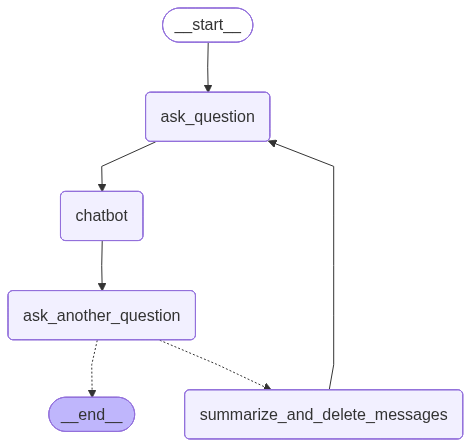

In [22]:
graph_compiled

In [23]:
graph_compiled.invoke(State(messages = []))


-------> ENTERING ask_question:
What is your question?


 Could you give me a grook by Piet Hein ?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet Hein ?
================================== Ai Message ==================================

Certainly! Here's a classic grook by Piet Hein:

**T.T.T.**

Put up in a place  
where it's easy to see  
the cryptic admonishment  
T. T. T.  

When you feel how depressingly  
slowly you climb,  
it's well to remember that  
Things Take Time.

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 yes



-------> ENTERING trim_messages:

Update the ongoing summary by incorporating the new lines of conversation below.  
Build upon the previous summary rather than repeating it so that the result  
reflects the most recent context and developments.

Previous Summary:


New Conversation:
ai: What is your question?

human: Could you give me a grook by Piet Hein ?

ai: Certainly! Here's a classic grook by Piet Hein:

**T.T.T.**

Put up in a place  
where it's easy to see  
the cryptic admonishment  
T. T. T.  

When you feel how depressingly  
slowly you climb,  
it's well to remember that  
Things Take Time.

ai: Would you like to ask one more question (yes/no)?

human: yes




-------> ENTERING ask_question:
What is your question?


 Where was the poet born ?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where was the poet born ?
================================== Ai Message ==================================

Piet Hein was born in Copenhagen, Denmark.

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='16aba49e-8e3e-4326-a2db-aa7449324504'),
  HumanMessage(content='Where was the poet born ?', additional_kwargs={}, response_metadata={}, id='20b1cb66-6c99-4940-a7dc-82b60056f130'),
  AIMessage(content='Piet Hein was born in Copenhagen, Denmark.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 126, 'total_tokens': 136, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_76fd112167', 'id': 'chatcmpl-DrVE8aSyyJDgkvWjHoHBmqp8OLkSJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ed23e-cf96-7db0-888f-dfd8b8b31724-0', usage_metadata={'input_tokens': 126, 'output_tokens': 10, '